In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv("../data/simulation_deviation.csv")

t = df["t"].to_numpy()
y1_true = df["m_dot"].to_numpy()
y2_true = df["Pp"].to_numpy()

# Contar apenas dados de validação
n = np.floor(len(t) / 2).astype(int)
y1_true = y1_true[n:]
y2_true = y2_true[n:]
t = t[n:] - t[n]  # Reiniciar tempo para 0


In [2]:
from scipy.io import loadmat

mat = loadmat("../data/output.mat")
ymod = np.array([mat["ymod"].T])[0]


In [3]:
# Transformar os dados em desvio para variavel de engenharia novamente
df2 = pd.read_csv("../data/simulation.csv")
offset = df2.iloc[0]
y1_true = y1_true + offset["m_dot"]
y2_true = y2_true + offset["Pp"]
y1 = ymod[0] + offset["m_dot"]
y2 = ymod[1] + offset["Pp"]


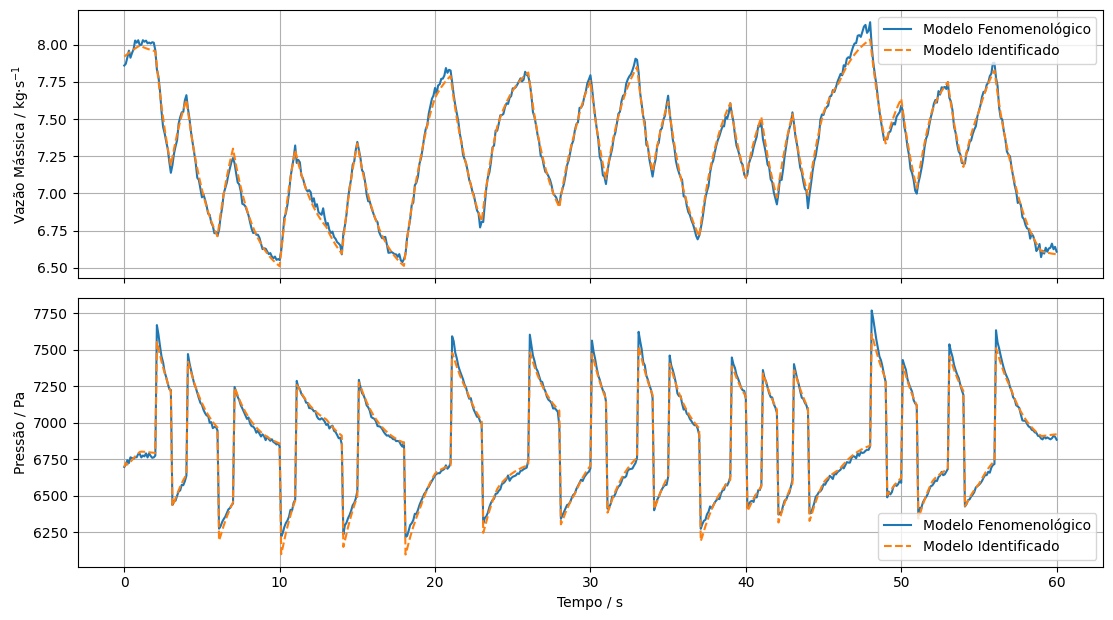

In [4]:
import matplotlib.pyplot as plt

# Gráficos
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(16 * 0.7, 9 * 0.7))

axs[0].plot(t, y1_true, label="Modelo Fenomenológico")
axs[0].plot(t, y1, label="Modelo Identificado", linestyle="--")
axs[0].set_ylabel("Vazão Mássica / kg·s$^{-1}$")

axs[1].plot(t, y2_true, label="Modelo Fenomenológico")
axs[1].plot(t, y2, label="Modelo Identificado", linestyle="--")
axs[1].set_ylabel("Pressão / Pa")

for ax in axs:
    ax.grid()
    ax.legend()
axs[-1].set_xlabel("Tempo / s")

plt.tight_layout()
plt.show()
